In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'sudoku.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img.shape

(563, 558)

In [3]:
block_sizes = [3, 11, 51]
c_values = [0, 5, 15]
methods = {'Mean': cv2.ADAPTIVE_THRESH_MEAN_C, 'Gaussian': cv2.ADAPTIVE_THRESH_GAUSSIAN_C}

results = {}
for name, method in methods.items():
    for b in block_sizes:
        for c in c_values:
            results[(name, b, c)] = cv2.adaptiveThreshold(img, 255, method, cv2.THRESH_BINARY, b, c)

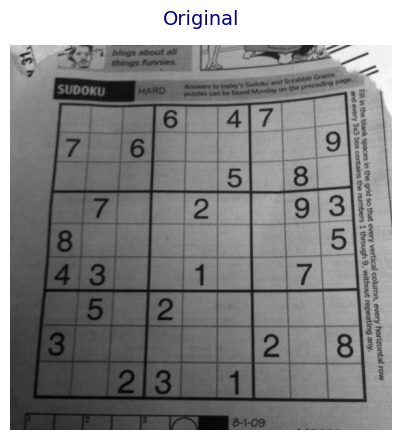

In [4]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(img, cmap='gray')
plt.title('Original', fontsize=14, color='darkblue', pad=15)
plt.show()

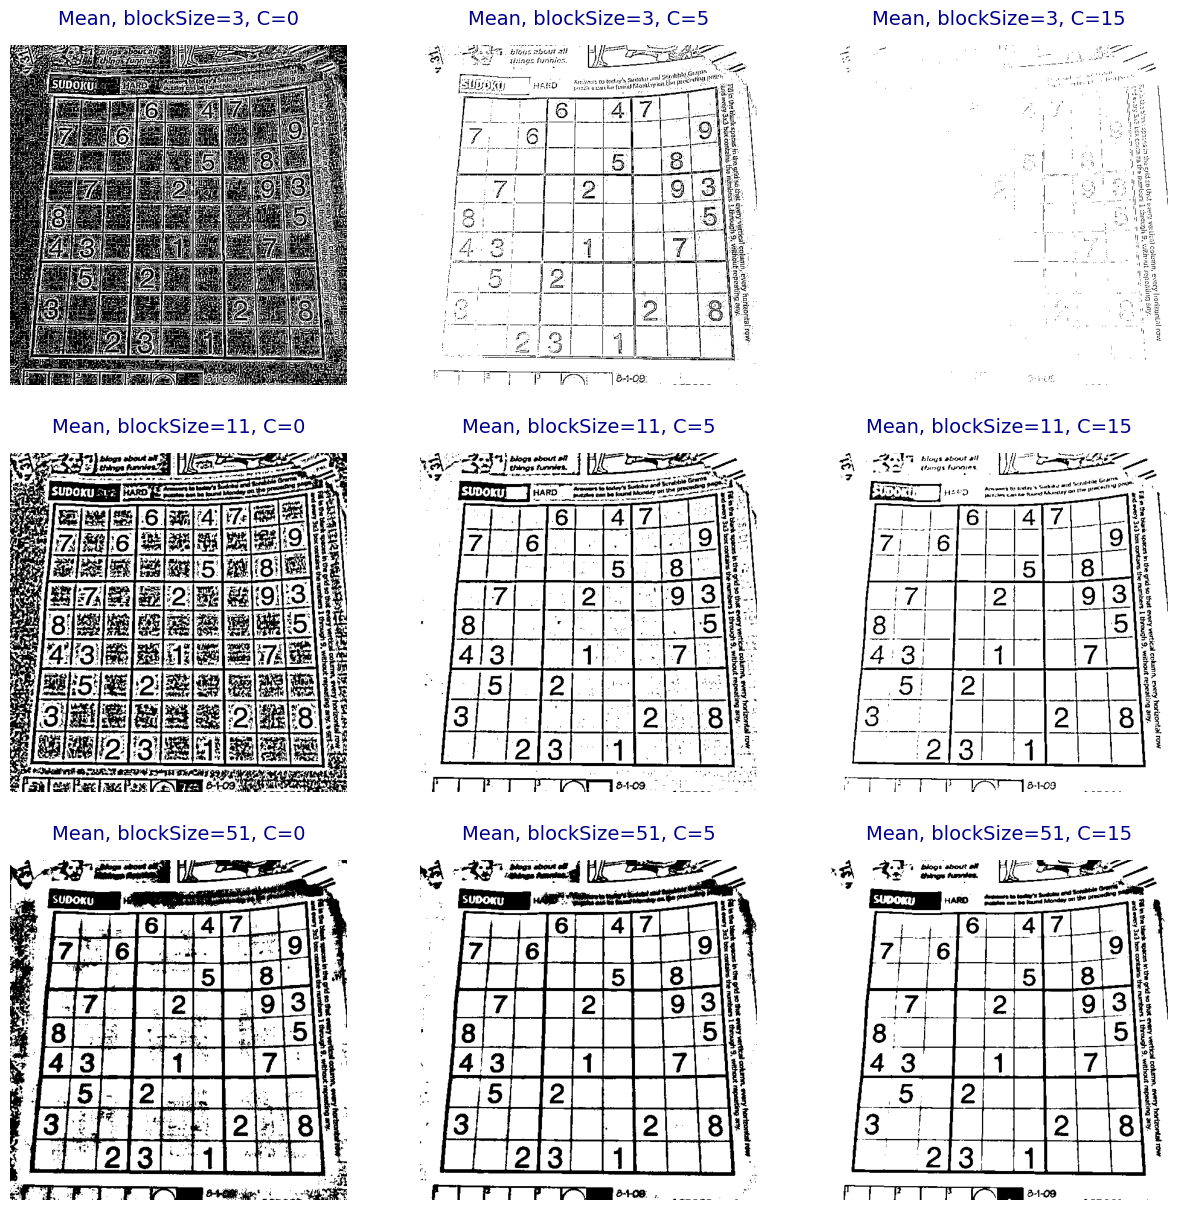

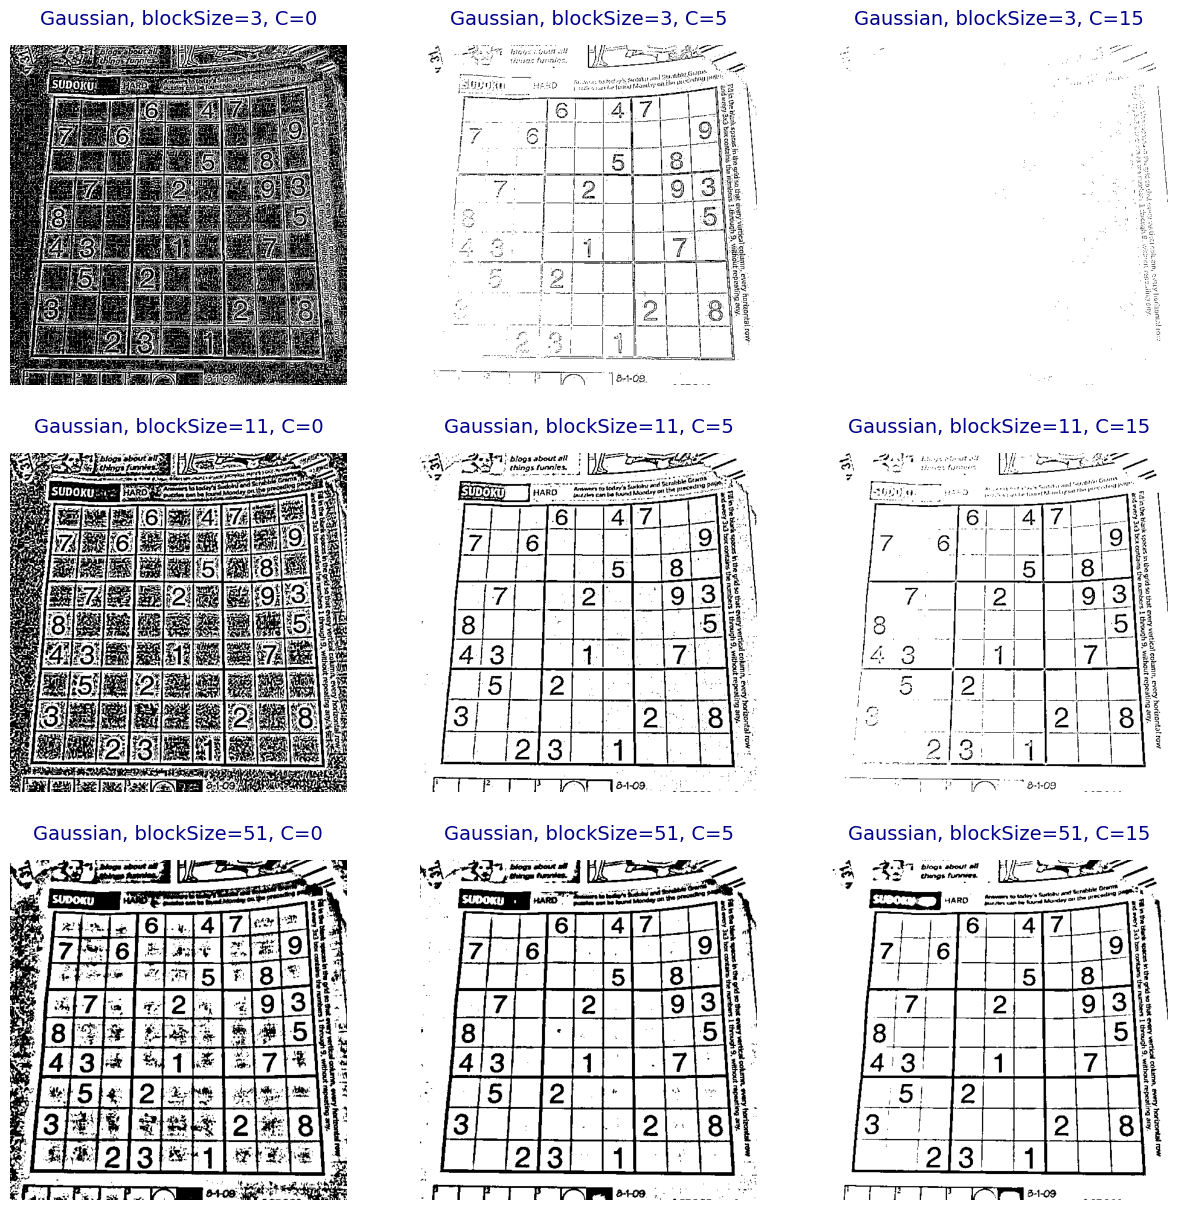

In [5]:
for name in methods:
    panels = [(f'{name}, blockSize={b}, C={c}', results[(name, b, c)]) for b in block_sizes for c in c_values]
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    for ax, (title, im) in zip(axes, panels):
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        ax.set_title(title, fontsize=14, color='darkblue', pad=15)

    plt.show()

In [6]:
for key, m in results.items():
    print(key, '- black pixels:', round(np.mean(m == 0), 3))

('Mean', 3, 0) - black pixels: 0.63
('Mean', 3, 5) - black pixels: 0.087
('Mean', 3, 15) - black pixels: 0.011
('Mean', 11, 0) - black pixels: 0.446
('Mean', 11, 5) - black pixels: 0.174
('Mean', 11, 15) - black pixels: 0.119
('Mean', 51, 0) - black pixels: 0.288
('Mean', 51, 5) - black pixels: 0.209
('Mean', 51, 15) - black pixels: 0.158
('Gaussian', 3, 0) - black pixels: 0.665
('Gaussian', 3, 5) - black pixels: 0.067
('Gaussian', 3, 15) - black pixels: 0.004
('Gaussian', 11, 0) - black pixels: 0.493
('Gaussian', 11, 5) - black pixels: 0.144
('Gaussian', 11, 15) - black pixels: 0.08
('Gaussian', 51, 0) - black pixels: 0.32
('Gaussian', 51, 5) - black pixels: 0.194
('Gaussian', 51, 15) - black pixels: 0.143


In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task2_best.png', results[('Gaussian', 51, 5)])

True

When the neighbourhood is too small (3), the threshold follows single pixels, so paper texture turns into noise and thick strokes become hollow.

When it is too large (51), it starts acting like a global threshold. With C=0 the shaded cells in the grid come out speckled.

When C is increased, fewer pixels turn black. C=0 gives 29-67% black (noise), C=5 is clean, and C=15 starts erasing thin characters (size 3 with C=15 loses almost everything).

The cleanest result is blockSize=51 with C=5. Size 11 with C=5 is close.

Mean and Gaussian are very similar. Gaussian is slightly cleaner at the same settings.